# House Prices Project

**Dataset**: [House Prices - Advanced Regression Techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data)

**Goal**: Predict the sale price of houses using statistical and machine learning methods.


---
## Setup and Imports

In [79]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Add your additional imports as needed
from sklearn import preprocessing
import statsmodels.api as sm
import torch

pd.set_option('display.max_columns', 100)
%matplotlib inline

---
## Setting the directory for data

In [4]:
dir("/Users/ljunodrstat/CStat2026_project/")
os.listdir()

['SalePrice_LogSalePrice.png',
 'CP_project_midterm_presentation.pptx',
 '.DS_Store',
 'report.md',
 'project_STUDENTID_processed.ipynb.zip',
 'Capture d’écran 2026-04-19 à 17.21.22.png',
 'Anova2.png',
 't_distribution_SalePriceMean180000.png',
 'README.md',
 'my_plot_skewed.png',
 'project_STUDENTID.ipynb',
 'Capture d’écran 2026-04-19 à 17.24.26.png',
 '.ipynb_checkpoints',
 '.jupyter',
 '.git',
 'Data',
 'project_STUDENTID_processed.ipynb']

---
## Load Data

In [5]:
train = pd.read_csv('Data/train.csv')
test = pd.read_csv('Data/test.csv')

print(f'Training set: {train.shape[0]} rows, {train.shape[1]} columns')
print(f'Test set: {test.shape[0]} rows, {test.shape[1]} columns')

train.head()

Training set: 1460 rows, 81 columns
Test set: 1459 rows, 80 columns


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


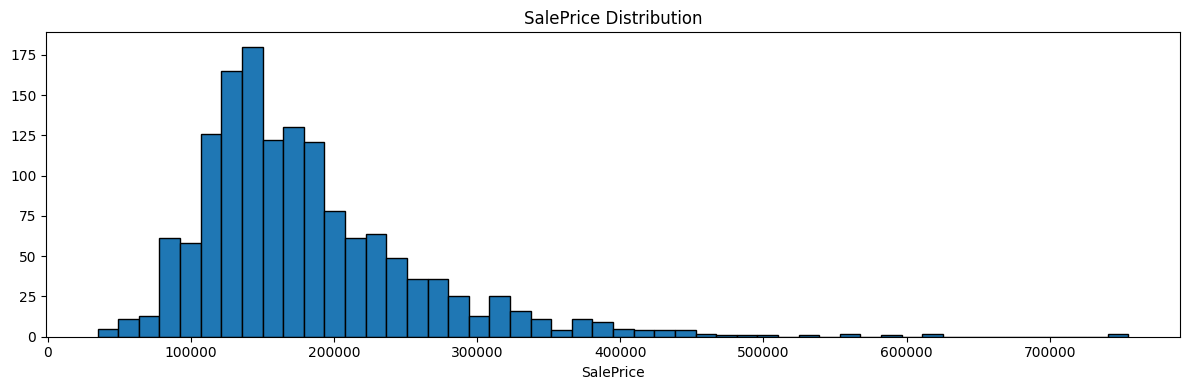

Skewness: 1.883


In [6]:
# Explore the target variable
print(train['SalePrice'].describe())

fig, axes = plt.subplots(1, 1, figsize=(12, 4))
axes.hist(train['SalePrice'], bins=50, edgecolor='black')
axes.set_title('SalePrice Distribution')
axes.set_xlabel('SalePrice')
plt.tight_layout()
plt.show()

print(f'Skewness: {train["SalePrice"].skew():.3f}')

The data is heavily skewed, what kind of transformation can we apply to make it more normal? 

A log transformation can bring a normal distribution

---
## Cleaning the data
Are there any NA values in the variables of interest for the project? If yes, how to replace them?

In [7]:
features = [
    'OverallQual', 'ExterQual', 'BsmtQual', 'KitchenQual', 'FireplaceQu', 
    'CentralAir', 'LotShape', 'LandSlope', 'MoSold', 'YrSold'
]

features_dt = train[features].copy()
print(f"{features_dt.head()}\n")

print("How many rows have missing values:")
print(features_dt[features_dt.isna().any(axis=1)].shape)

   OverallQual ExterQual BsmtQual KitchenQual FireplaceQu CentralAir LotShape  \
0            7        Gd       Gd          Gd         NaN          Y      Reg   
1            6        TA       Gd          TA          TA          Y      Reg   
2            7        Gd       Gd          Gd          TA          Y      IR1   
3            7        TA       TA          Gd          Gd          Y      IR1   
4            8        Gd       Gd          Gd          TA          Y      IR1   

  LandSlope  MoSold  YrSold  
0       Gtl       2    2008  
1       Gtl       5    2007  
2       Gtl       9    2008  
3       Gtl       2    2006  
4       Gtl      12    2008  

How many rows have missing values:
(699, 10)


In [8]:
for col in features_dt.columns:
    print(f"Distinct values in {col}: {features_dt[col].unique()}")

Distinct values in OverallQual: [ 7  6  8  5  9  4 10  3  1  2]
Distinct values in ExterQual: ['Gd' 'TA' 'Ex' 'Fa']
Distinct values in BsmtQual: ['Gd' 'TA' 'Ex' nan 'Fa']
Distinct values in KitchenQual: ['Gd' 'TA' 'Ex' 'Fa']
Distinct values in FireplaceQu: [nan 'TA' 'Gd' 'Fa' 'Ex' 'Po']
Distinct values in CentralAir: ['Y' 'N']
Distinct values in LotShape: ['Reg' 'IR1' 'IR2' 'IR3']
Distinct values in LandSlope: ['Gtl' 'Mod' 'Sev']
Distinct values in MoSold: [ 2  5  9 12 10  8 11  4  1  7  3  6]
Distinct values in YrSold: [2008 2007 2006 2009 2010]


## NaN Values 
We observe nan values in two variables: "BsmtQual" and "FireplaceQu", which means the feature is absent, according to the data description file.

**Solution**<br>
We replace them with None for clarity purpose.

## Ordinal Values
6 variables ("ExterQual", "BsmtQual", "KitchenQual", "FireplaceQu", "LotShape", "LandSlope") are ordinal values, ranking quality intp different levels (4 ranks in general, 3 for the "LandSlope").

**Solution**<br>
Unlike "OverallQual", which is already numeric, we need to correct them by adding a rank, using a dictionnary. 

In [9]:
features_dt['BsmtQual'] = features_dt['BsmtQual'].fillna('No_Basement')
features_dt['FireplaceQu'] = features_dt['FireplaceQu'].fillna('No_Fireplace')

print(features_dt['FireplaceQu'].unique())
print(features_dt['BsmtQual'].unique())

['No_Fireplace' 'TA' 'Gd' 'Fa' 'Ex' 'Po']
['Gd' 'TA' 'Ex' 'No_Basement' 'Fa']


## Dictionaries

In [10]:
qual_dict = {
    'Ex': 5,
    'Gd': 4,
    'TA': 3,
    'Fa': 2,
    'Po': 1,
    'NA': 0,
    'No_Basement': 0,
    'No_Fireplace': 0,
    'No_Kitchen': 0
}

slope_dict = {
    'Gtl': 3,
    'Mod': 2,
    'Sev': 1,   
    'NA': 0
}

lotshape_dict = {
    'Reg': 4,
    'IR1': 3,
    'IR2': 2,
    'IR3': 1,
    'NA': 0
}

features_dt['ExterQual'] = features_dt['ExterQual'].map(qual_dict)
features_dt['BsmtQual'] = features_dt['BsmtQual'].map(qual_dict)
features_dt['KitchenQual'] = features_dt['KitchenQual'].map(qual_dict)
features_dt['FireplaceQu'] = features_dt['FireplaceQu'].map(qual_dict)

features_dt['LotShape'] = features_dt['LotShape'].map(lotshape_dict)
features_dt['LandSlope'] = features_dt['LandSlope'].map(slope_dict)

print(f"{features_dt.head()}\n")
print(features_dt.isna().sum())

   OverallQual  ExterQual  BsmtQual  KitchenQual  FireplaceQu CentralAir  \
0            7          4         4            4            0          Y   
1            6          3         4            3            3          Y   
2            7          4         4            4            3          Y   
3            7          3         3            4            4          Y   
4            8          4         4            4            3          Y   

   LotShape  LandSlope  MoSold  YrSold  
0         4          3       2    2008  
1         4          3       5    2007  
2         3          3       9    2008  
3         3          3       2    2006  
4         3          3      12    2008  

OverallQual    0
ExterQual      0
BsmtQual       0
KitchenQual    0
FireplaceQu    0
CentralAir     0
LotShape       0
LandSlope      0
MoSold         0
YrSold         0
dtype: int64


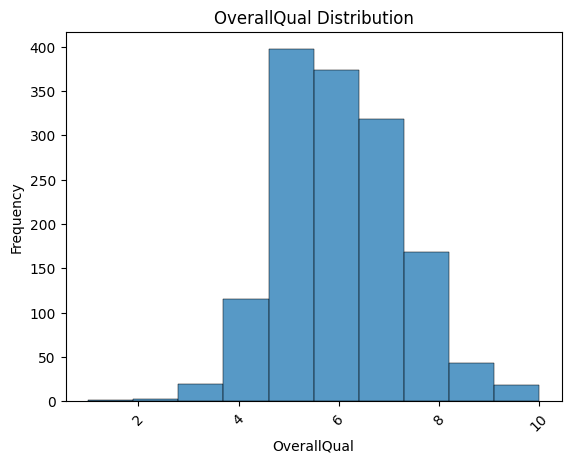

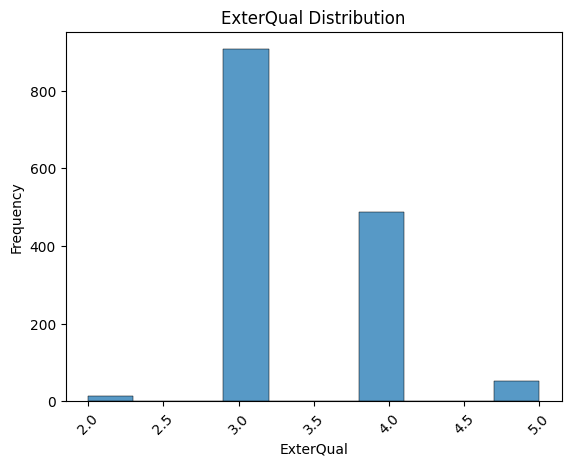

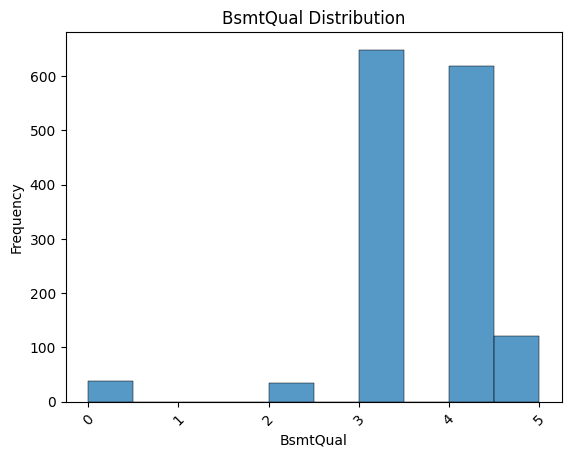

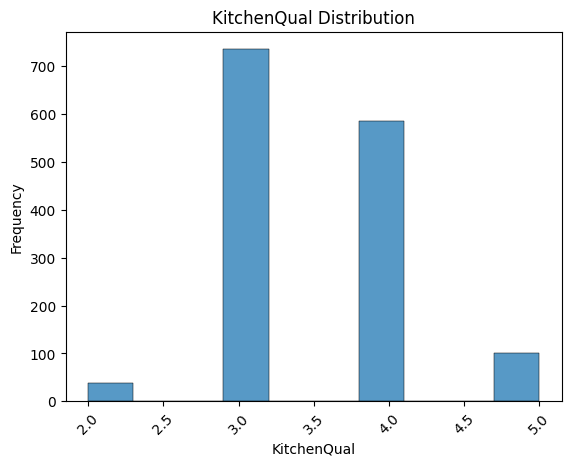

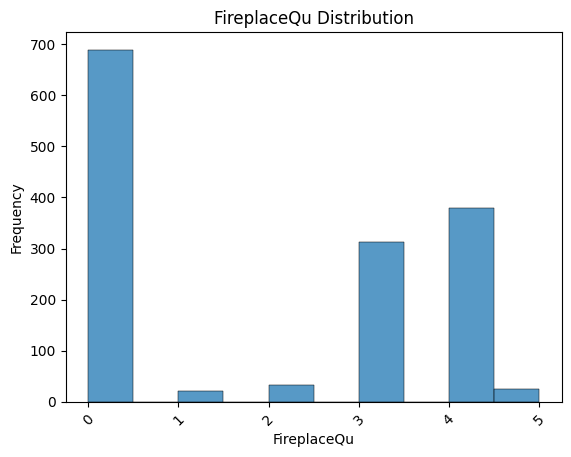

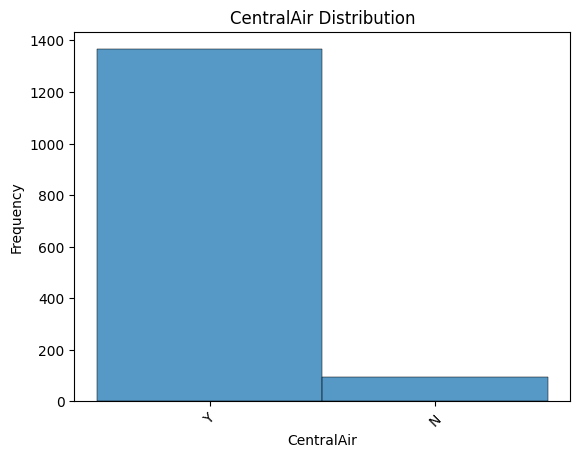

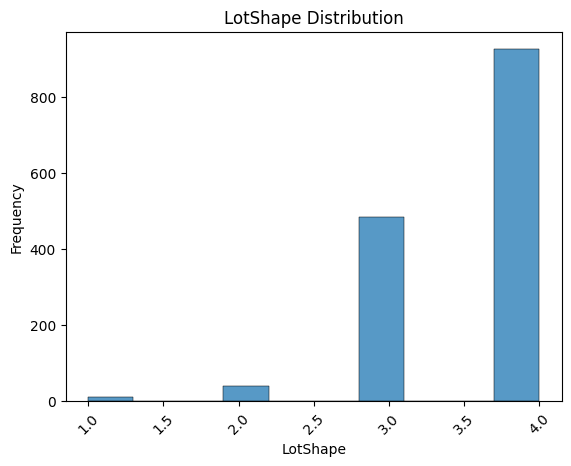

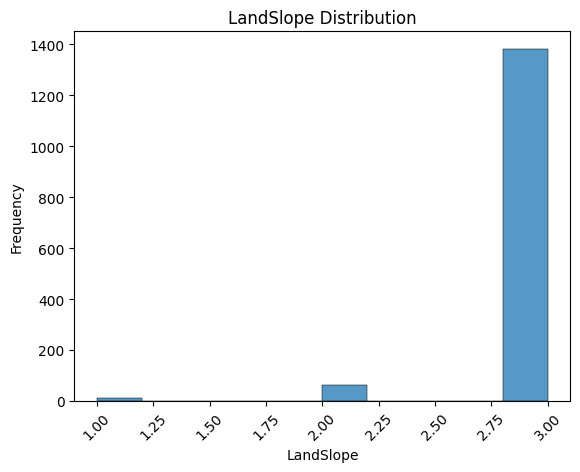

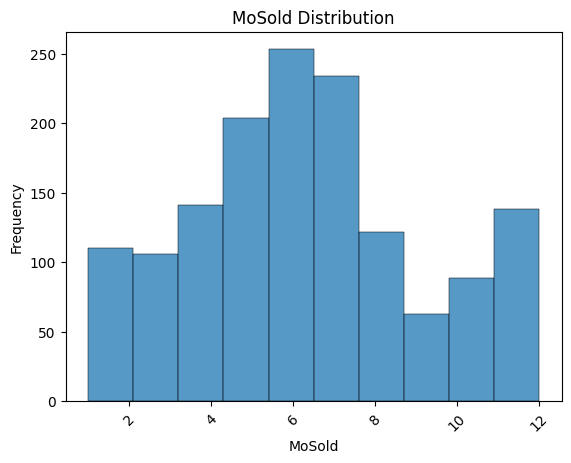

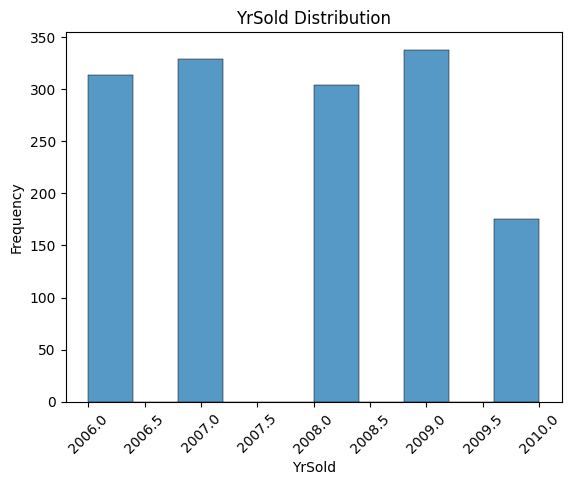

In [11]:
for col in features_dt.columns:
    sns.histplot(features_dt[col], kde=False, bins=10, edgecolor='black', linewidth=0.35)
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.show()

The corrections are valid - we now apply the same encoding to the train dataframe.

In [12]:
# Same encoding for the train dataframe

---
## Part 1: Classical Statistical Inference



Apply basic statistical methods to explore the data:
- **Sample mean and variance** of `SalePrice` and key features
- **Confidence intervals** for the mean SalePrice
- **Hypothesis testing** — e.g. is the mean SalePrice significantly different from \$180,000? Is the distribution of the transformed `SalePrice` normal (Shapiro-Wilk)?
- Visualize distributions and support your conclusions with plots

Sample Mean and Variance of SalePrice and key features


In [13]:
train['LogSalePrice'] = np.log(train['SalePrice'])

mean_LogSalePrice = train['LogSalePrice'].mean()
median_LogSalePrice = train['LogSalePrice'].median()
std_LogSalePrice = train['LogSalePrice'].std()
print(f'Mean: {mean_LogSalePrice:.2f}')
print(f'Median: {median_LogSalePrice:.2f}')
print(f'Standard Deviation: {std_LogSalePrice:.2f}')

Mean: 12.02
Median: 12.00
Standard Deviation: 0.40


In [14]:
mean_SalePrice = train['SalePrice'].mean()
median_SalePrice = train['SalePrice'].median()
std_SalePrice = train['SalePrice'].std()
print(f'Mean: {mean_SalePrice:.2f}')
print(f'Median: {median_SalePrice:.2f}')
print(f'Standard Deviation: {std_SalePrice:.2f}')

Mean: 180921.20
Median: 163000.00
Standard Deviation: 79442.50


### Feature classification by type

In [15]:
ordinal_mappings = {
    'ExterQual' : qual_dict,
    'BsmtQual' : qual_dict,
    'KitchenQual' : qual_dict,
    'FireplaceQu' : qual_dict,
    'LotShape' : lotshape_dict,
    'LandSlope' : slope_dict
}


def describe_features(df, feature, ordinal_mappings=None):
    if ordinal_mappings:
        mapped = df[feature].map(ordinal_mappings)
        valid = mapped.dropna()

        print(f"\n{feature} (ordinal ):")
        print(f"  Uniques values : {df[feature].unique()}")
        print(f" Distribution:\n{valid.value_counts().sort_index()}")
        print(f"  Mean: {valid.mean():.2f}, Median: {valid.median():.2f}, Std Dev: {valid.std():.2f}")
        print(f" Min-Max : {valid.min()} - {valid.max()}")
        print(f" Missing values: {df[feature].isna().sum()}")
    elif pd.api.types.is_numeric_dtype(df[feature]):
        valid = df[feature].dropna()
        print(f"\n{feature} (numerical):")
        print(f" Mean : {valid.mean():.2f}, Median: {valid.median():.2f}, Std Dev: {valid.std():.2f}")
        print(f" Min-Max : {valid.min()} - {valid.max()}")
        print(f" Q1 : {valid.quantile(0.25)}, Q3: {valid.quantile(0.75)}")
        print(f" Missing values: {df[feature].isna().sum()}")
    else: 
        print(f"\n{feature} (categorical):")
        print(f" Unique values: {df[feature].unique()}")
        print(f" Top values :\n {df[feature].nunique()}")
        print(f" Missing values: {df[feature].isna().sum()}")

In [16]:
features_ordinal = train[['ExterQual', 'BsmtQual', 'KitchenQual', 'FireplaceQu', 'LotShape', 'LandSlope']]
features_numerical = train[['SalePrice', 'OverallQual', 'MoSold', 'YrSold']]


In [17]:
print("==== Target : Numerical variables =====")
for feat in features_numerical.columns:
    describe_features(train, feat)

==== Target : Numerical variables =====

SalePrice (numerical):
 Mean : 180921.20, Median: 163000.00, Std Dev: 79442.50
 Min-Max : 34900 - 755000
 Q1 : 129975.0, Q3: 214000.0
 Missing values: 0

OverallQual (numerical):
 Mean : 6.10, Median: 6.00, Std Dev: 1.38
 Min-Max : 1 - 10
 Q1 : 5.0, Q3: 7.0
 Missing values: 0

MoSold (numerical):
 Mean : 6.32, Median: 6.00, Std Dev: 2.70
 Min-Max : 1 - 12
 Q1 : 5.0, Q3: 8.0
 Missing values: 0

YrSold (numerical):
 Mean : 2007.82, Median: 2008.00, Std Dev: 1.33
 Min-Max : 2006 - 2010
 Q1 : 2007.0, Q3: 2009.0
 Missing values: 0


In [18]:
features_ordinal.head()

,ExterQual,BsmtQual,KitchenQual,FireplaceQu,LotShape,LandSlope
0,Gd,Gd,Gd,NaN,Reg,Gtl
1,TA,Gd,TA,TA,Reg,Gtl
2,Gd,Gd,Gd,TA,IR1,Gtl
3,TA,TA,Gd,Gd,IR1,Gtl
4,Gd,Gd,Gd,TA,IR1,Gtl


In [19]:
print("\n=== Ordinal features ==== ")
for feat in features_ordinal.columns:
        describe_features(train, feat)


=== Ordinal features ==== 

ExterQual (categorical):
 Unique values: ['Gd' 'TA' 'Ex' 'Fa']
 Top values :
 4
 Missing values: 0

BsmtQual (categorical):
 Unique values: ['Gd' 'TA' 'Ex' nan 'Fa']
 Top values :
 4
 Missing values: 37

KitchenQual (categorical):
 Unique values: ['Gd' 'TA' 'Ex' 'Fa']
 Top values :
 4
 Missing values: 0

FireplaceQu (categorical):
 Unique values: [nan 'TA' 'Gd' 'Fa' 'Ex' 'Po']
 Top values :
 5
 Missing values: 690

LotShape (categorical):
 Unique values: ['Reg' 'IR1' 'IR2' 'IR3']
 Top values :
 4
 Missing values: 0

LandSlope (categorical):
 Unique values: ['Gtl' 'Mod' 'Sev']
 Top values :
 3
 Missing values: 0


## Confidence intervals 
### for the mean SalePrice

In [20]:
mean_SalePrice = train['SalePrice'].mean()
std_SalePrice = train['SalePrice'].std()
n = len(train)
stat_err = stats.sem(train['SalePrice'], nan_policy='omit')
confidence = 0.95
degrees_freedom = n - 1
confidence_interval = stats.t.interval(confidence, degrees_freedom, loc=mean_SalePrice, scale=stat_err)

print(f"95% Confidence Interval for SalePrice: {confidence_interval[0]:.2f} to {confidence_interval[1]:.2f}")

95% Confidence Interval for SalePrice: 176842.84 to 184999.55


In [21]:
mean_LogSalePrice = train['LogSalePrice'].mean()
std_LogSalePrice = train['LogSalePrice'].std()
n_log = len(train)
stat_err_log = stats.sem(train['LogSalePrice'], nan_policy='omit')
confidence = 0.95
degrees_freedom = n_log - 1
confidence_interval_log = stats.t.interval(confidence, degrees_freedom, loc=mean_LogSalePrice, scale=stat_err_log)

print(f"95% Confidence Interval for LogSalePrice: {confidence_interval_log[0]:.2f} to {confidence_interval_log[1]:.2f}")

95% Confidence Interval for LogSalePrice: 12.00 to 12.04


<Axes: xlabel='LogSalePrice', ylabel='Count'>

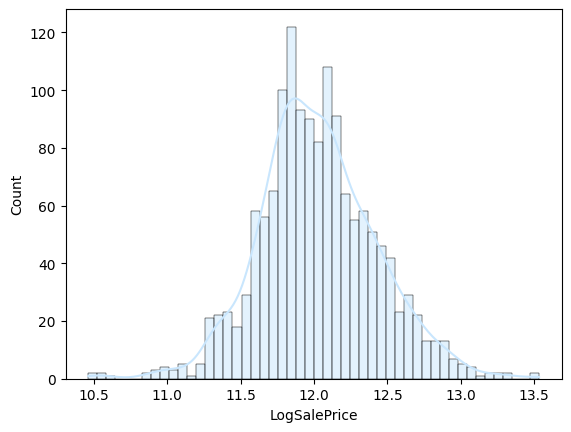

In [22]:
sns.histplot(train['LogSalePrice'], kde=True, bins=50, color='#c9e6fd', edgecolor='black', linewidth=0.35)

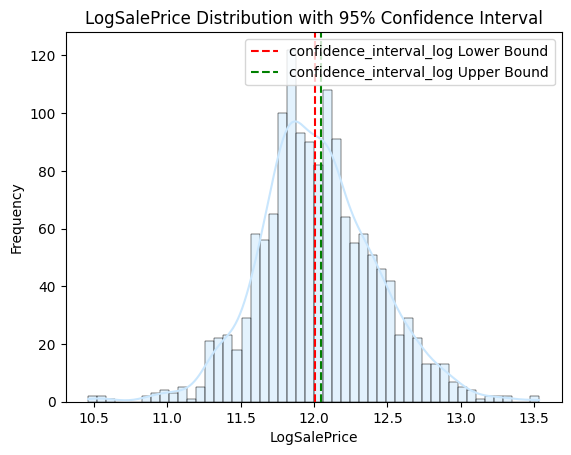

In [23]:
sns.histplot(train['LogSalePrice'], kde=True, bins=50, color='#c9e6fd', edgecolor='black', linewidth=0.35)
plt.axvline(confidence_interval_log[0], color='red', linestyle='--', label='confidence_interval_log Lower Bound')
plt.axvline(confidence_interval_log[1], color='green', linestyle='--', label='confidence_interval_log Upper Bound')
plt.title('LogSalePrice Distribution with 95% Confidence Interval')
plt.xlabel('LogSalePrice')
plt.ylabel('Frequency')
plt.legend()
plt.show()

## Hypothesis testing
 — e.g. is the mean SalePrice significantly different from \$180,000? Is the distribution of the transformed `SalePrice` normal (Shapiro-Wilk)?

In [24]:
hypothetisis_value = 180000
hypothetisis_value_log = np.log(hypothetisis_value)
t_statistic, p_value = stats.ttest_1samp(train['LogSalePrice'], popmean=hypothetisis_value_log, nan_policy='omit')
print(f"T-statistic: {t_statistic:.3f}, P-value: {p_value:.3f}")

T-statistic: -7.333, P-value: 0.000


In [25]:
shapiro_stat, shapiro_p = stats.shapiro(train['LogSalePrice'].dropna())
print(f"Shapiro-Wilk Test: Statistic={shapiro_stat:.3f}, P-value={shapiro_p:.3f}")

Shapiro-Wilk Test: Statistic=0.991, P-value=0.000


Skewness after log transformation: 0.121


<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\s'
/var/folders/b7/9lwv5j_54qqfrk_k5p5mmtn00000gn/T/ipykernel_65642/1960538830.py:12: SyntaxWarning: invalid escape sequence '\m'
  axes[i].plot(x, p, 'k', linewidth=2, label=f'Normal Fit($\mu$={mu:.2f}, $\sigma$={std:.2f})')
/var/folders/b7/9lwv5j_54qqfrk_k5p5mmtn00000gn/T/ipykernel_65642/1960538830.py:12: SyntaxWarning: invalid escape sequence '\s'
  axes[i].plot(x, p, 'k', linewidth=2, label=f'Normal Fit($\mu$={mu:.2f}, $\sigma$={std:.2f})')


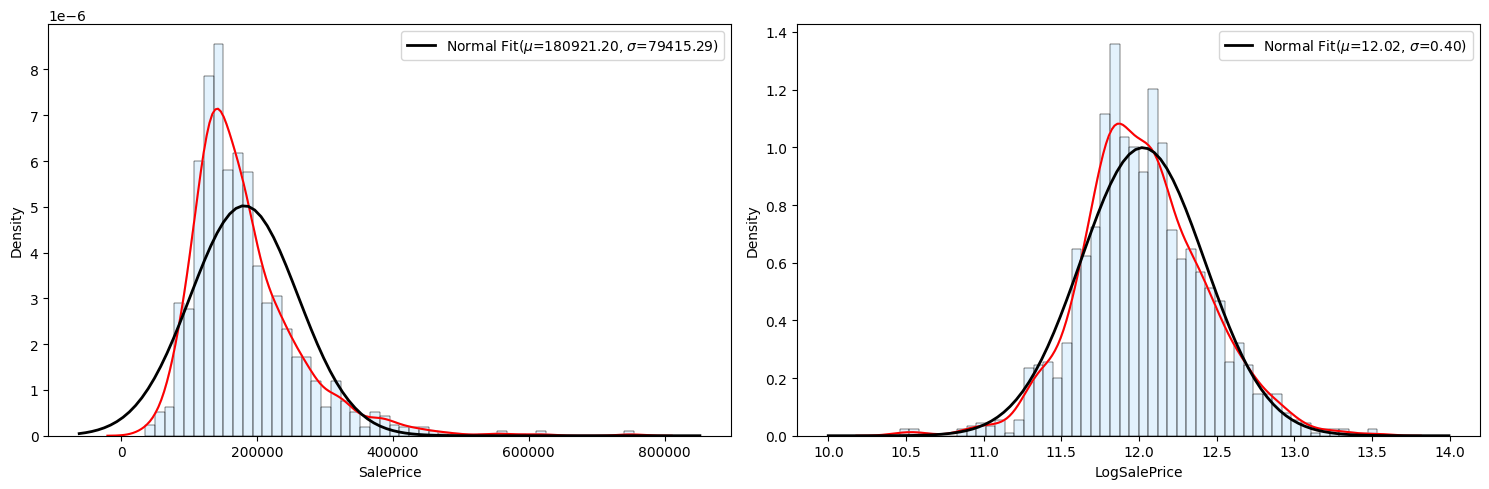

In [26]:
print(f'Skewness after log transformation: {train["LogSalePrice"].skew():.3f}')
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
cols = ['SalePrice', 'LogSalePrice']
for i, col in enumerate(cols):
    sns.histplot(train[col], bins=50, ax=axes[i],
                stat='density', kde=True, color='#c9e6fd', edgecolor='black', linewidth=0.35)
    sns.kdeplot(train[col], ax=axes[i], color='red', linewidth=1.5)
    mu, std = stats.norm.fit(train[col])
    xmin, xmax = axes[i].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, mu, std)
    axes[i].plot(x, p, 'k', linewidth=2, label=f'Normal Fit($\mu$={mu:.2f}, $\sigma$={std:.2f})')
    axes[i].legend()
plt.tight_layout()
plt.show()

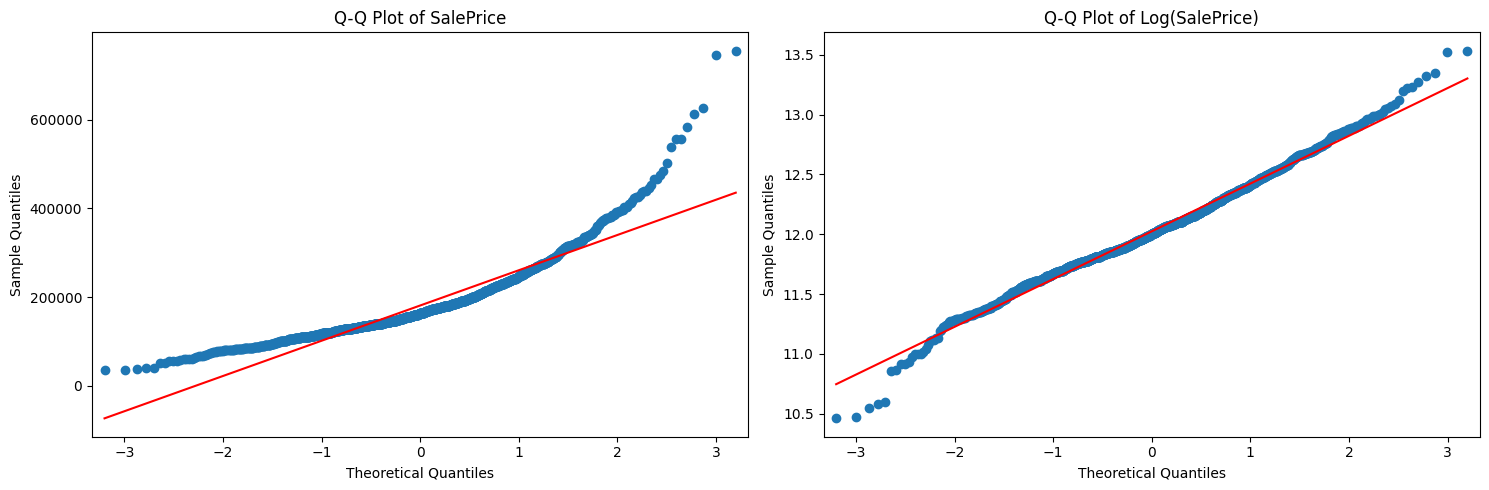

In [27]:
#Q-Q plot for SalePrice
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sm.qqplot(train['SalePrice'], line='s', ax=axes[0])
sm.qqplot(train['LogSalePrice'], line='s', ax=axes[1])
axes[0].set_title('Q-Q Plot of SalePrice')
axes[1].set_title('Q-Q Plot of Log(SalePrice)')

plt.tight_layout()
plt.show()

In [28]:
#Shapiro-Wilk test for SalePrice
shapiro_test = stats.shapiro(train['LogSalePrice'])
print(f'Shapiro-Wilk test statistic: {shapiro_test.statistic:.3f}, p-value: {shapiro_test.pvalue:.3e}')

Shapiro-Wilk test statistic: 0.991, p-value: 1.149e-07


The Q-Q plots and Shapiro-Wilk test ($H_0$: normal distribution) confirm that the log transformation of SalePrice yields an approximately normal distribution (p-value < 0.05).

## Missing Values

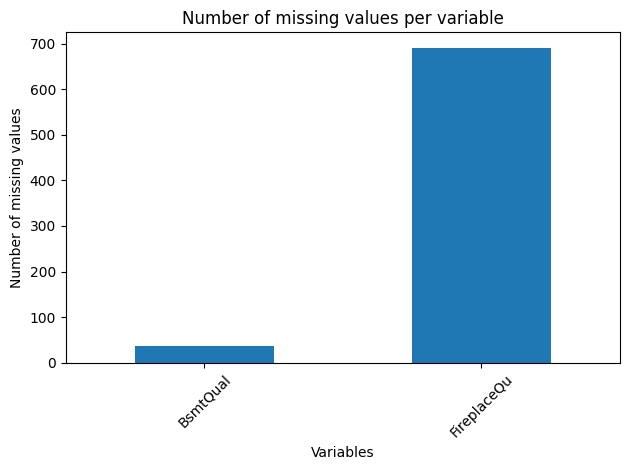

In [29]:
features = [
    'OverallQual', 'ExterQual', 'BsmtQual', 'KitchenQual', 'FireplaceQu', 
    'CentralAir', 'LotShape', 'LandSlope', 'MoSold', 'YrSold'
]
train_null = train[features]
missing_pd = train_null.isnull()
missing = missing_pd.sum()
missing = missing[missing > 0]
missing.sort_values(inplace=True)
missing.plot.bar()
plt.title('Number of missing values per variable')
plt.ylabel('Number of missing values')
plt.xlabel('Variables')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
#sns.histplot(train_null['OverallQual'], kde=False)
train[features].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   OverallQual  1460 non-null   int64 
 1   ExterQual    1460 non-null   object
 2   BsmtQual     1423 non-null   object
 3   KitchenQual  1460 non-null   object
 4   FireplaceQu  770 non-null    object
 5   CentralAir   1460 non-null   object
 6   LotShape     1460 non-null   object
 7   LandSlope    1460 non-null   object
 8   MoSold       1460 non-null   int64 
 9   YrSold       1460 non-null   int64 
dtypes: int64(3), object(7)
memory usage: 114.2+ KB


## Analysis of TotalBsmtSF

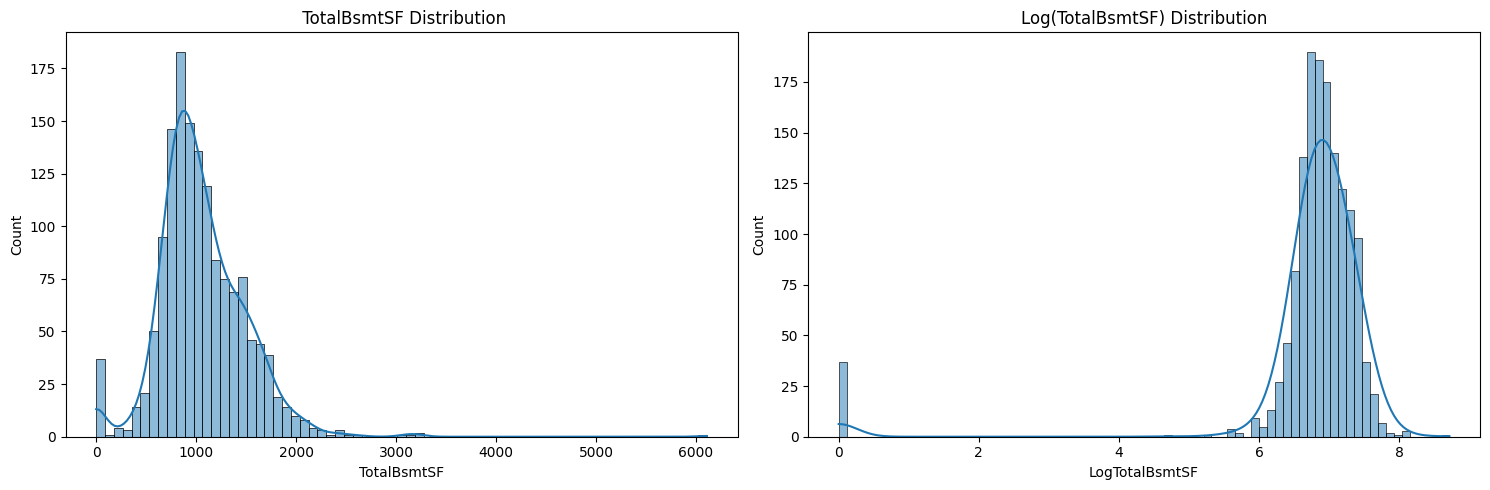

In [31]:
train['TotalBsmtSF']
train['LogTotalBsmtSF'] = np.log1p(train['TotalBsmtSF'])
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].set_title(' TotalBsmtSF Distribution')
sns.histplot(train['TotalBsmtSF'], kde=True, ax=axes[0])
axes[1].set_title('Log(TotalBsmtSF) Distribution')
sns.histplot(train['LogTotalBsmtSF'], kde=True, ax=axes[1])
plt.tight_layout()
plt.show()

In [32]:
TotalBsmtSF_skew = train['TotalBsmtSF'].skew()
LogTotalBsmtSF_skew = train['LogTotalBsmtSF'].skew()
print(f'Skewness of TotalBsmtSF: {TotalBsmtSF_skew:.3f}')
print(f'Skewness of Log(TotalBsmtSF): {LogTotalBsmtSF_skew:.3f}')

Skewness of TotalBsmtSF: 1.524
Skewness of Log(TotalBsmtSF): -5.155


In [33]:
LogGrLivArea = np.log(train['GrLivArea'])
LogTotalBsmtSF = np.log1p(train['TotalBsmtSF'])
LogTotalBsmtSF_skew = LogTotalBsmtSF.skew()
LogGrLivArea_skew = LogGrLivArea.skew()
print(f'Skewness of Log(TotalBsmtSF): {LogTotalBsmtSF_skew:.3f}')
print(f'Skewness of Log(GrLivArea): {LogGrLivArea_skew:.3f}')

Skewness of Log(TotalBsmtSF): -5.155
Skewness of Log(GrLivArea): -0.007


Skewness of Log(TotalBsmtSF): -5.155


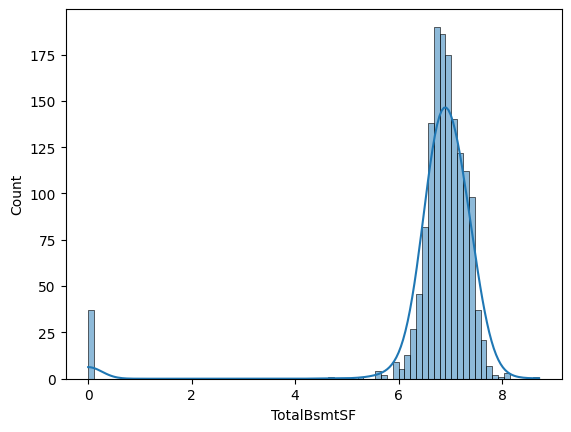

In [34]:
sns.histplot(LogTotalBsmtSF, kde=True)
LogTotalBsmtSF_skew=LogTotalBsmtSF.skew()
print(f'Skewness of Log(TotalBsmtSF): {LogTotalBsmtSF_skew:.3f}')

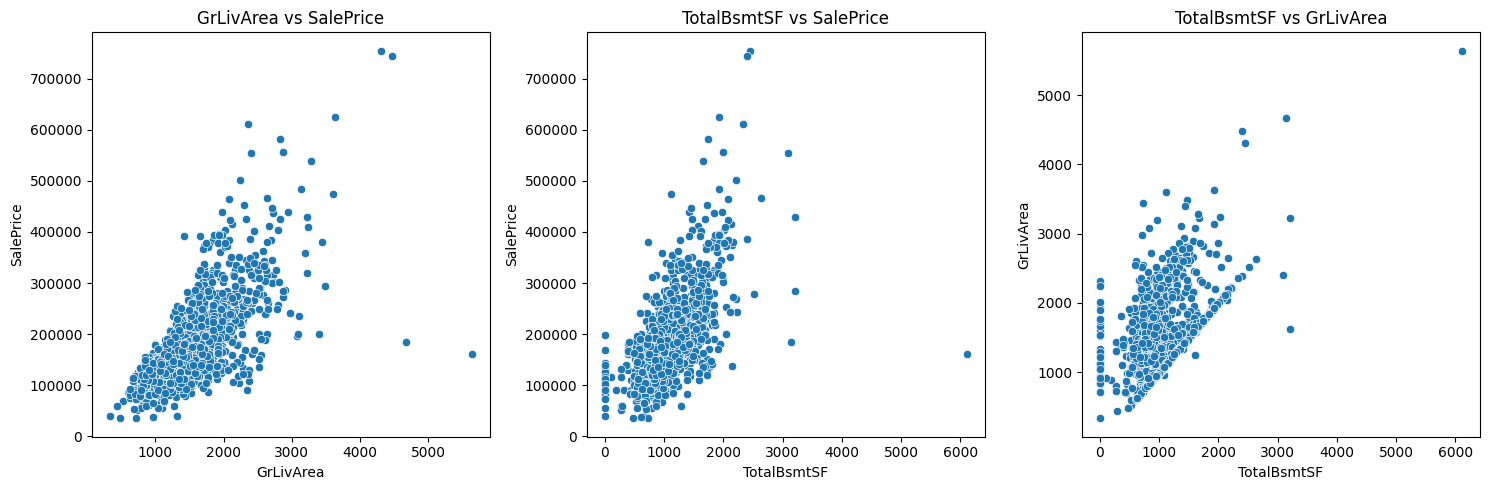

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=train, ax=axes[0])
axes[0].set_title('GrLivArea vs SalePrice')
sns.scatterplot(x='TotalBsmtSF', y='SalePrice', data=train, ax=axes[1])
axes[1].set_title('TotalBsmtSF vs SalePrice')
sns.scatterplot(x='TotalBsmtSF', y='GrLivArea', data=train, ax=axes[2])
axes[2].set_title('TotalBsmtSF vs GrLivArea')
plt.tight_layout()

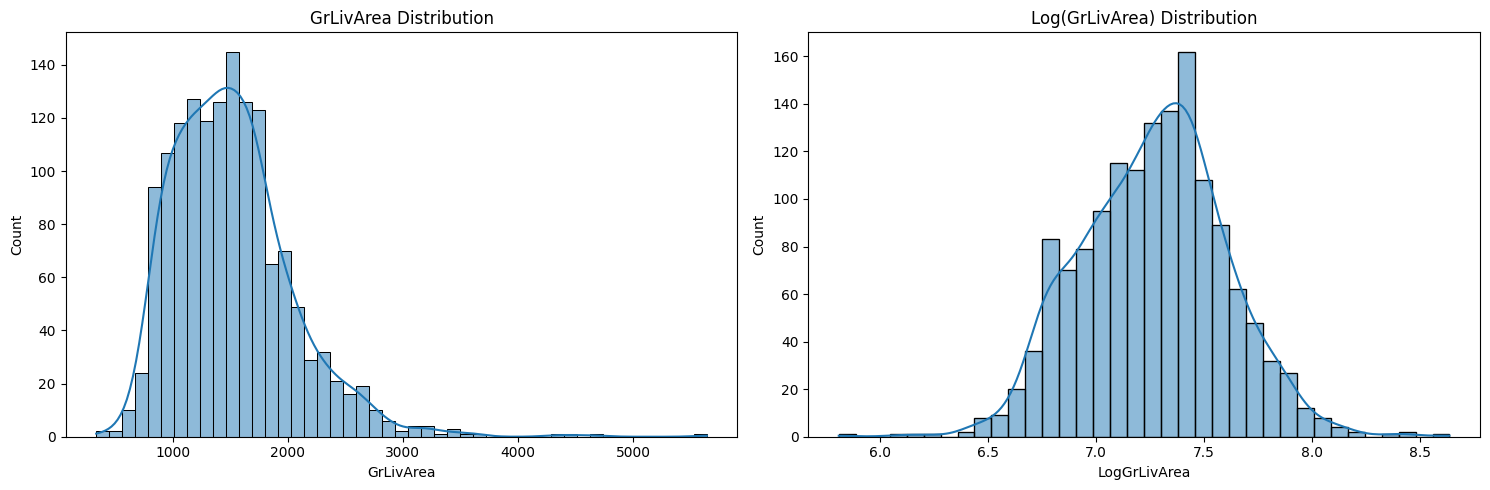

In [36]:
train['LogGrLivArea'] = np.log(train['GrLivArea'])
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].set_title('GrLivArea Distribution')
sns.histplot(train['GrLivArea'], kde=True, ax=axes[0])
axes[1].set_title('Log(GrLivArea) Distribution')
sns.histplot(train['LogGrLivArea'], kde=True, ax=axes[1])
plt.tight_layout()
plt.show()

In [37]:
# CI for the mean SalePrice (95%)
alpha = 0.05
mean = np.mean(train['SalePrice'])               # Mean
s = np.std(train['SalePrice'], ddof = 1)         # Standard deviation
se = s/np.sqrt(n)                                # Standard error
t_critical_value = stats.t.ppf(1-alpha/2, df=n - 1)  # (two-tailed)
low_bound = mean - t_critical_value * se         # Lower bound
up_bound = mean + t_critical_value * se          # Upper bound

print(f"Mean: {mean:,.2f}")
print(f"CI: [{low_bound:,.2f}, {up_bound:,.2f}]")

Mean: 180,921.20
CI: [176,842.84, 184,999.55]


In [38]:
# Hypothesis testing: is the mean SalePrice significantly different from $180,000?
mu0 = 180000
dof = n - 1
T = (mean - mu0) / se
p_value = 2 * (1 - stats.t.cdf(abs(T), df=dof))

print(f"T statistic: {T}")
print(f"p-value: {p_value}")

print(p_value < alpha)

T statistic: 0.44307321990459303
p-value: 0.6577784607522805
False


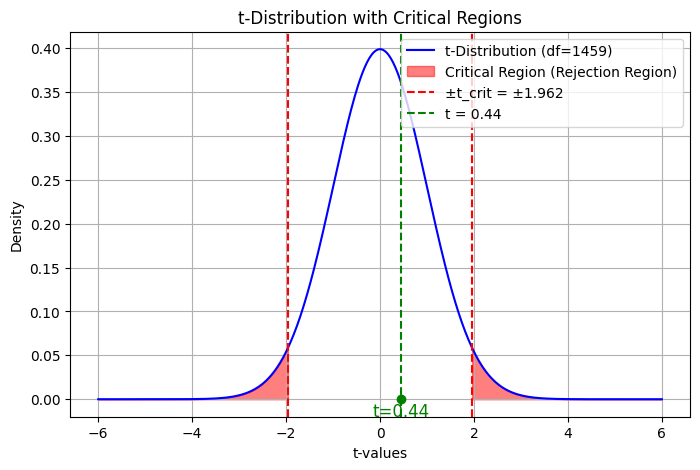

In [39]:
x = np.linspace(-6, 6, 500)
y = stats.t.pdf(x, dof)

plt.figure(figsize=(8, 5))
plt.plot(x, y, label=f"t-Distribution (df={dof})", color="blue")

# critical region (two-tailed test)
x_critical_left = np.linspace(-6, -t_critical_value, 300)
x_critical_right = np.linspace(t_critical_value, 6, 300)
plt.fill_between(x_critical_left, stats.t.pdf(x_critical_left, dof), color='red', alpha=0.5, label='Critical Region (Rejection Region)')
plt.fill_between(x_critical_right, stats.t.pdf(x_critical_right, dof), color='red', alpha=0.5)

plt.axvline(-t_critical_value, color="red", linestyle="--", label=f"±t_crit = ±{t_critical_value:.3f}")
plt.axvline(t_critical_value, color="red", linestyle="--")

plt.axvline(T, color='green', linestyle='--', label=f't = {round(T,2)}')
plt.scatter([T], [0], color='green', zorder=3)  # Mark the t-value on the x-axis
plt.text(T, -0.02, f't={round(T,2)}', color='green', fontsize=12, ha='center')

plt.title('t-Distribution with Critical Regions')
plt.xlabel('t-values')
plt.ylabel('Density')
plt.legend()
plt.grid()
plt.show()

---
## Part 2: ANOVA — Finding Significant Features

Use ANOVA to determine which of the following **10 features** have a statistically significant effect on the transformed SalePrice. 

**Given features (10):**

| # | Feature | Levels | Description |
|---|---|---|---|
| 1 | `OverallQual` | 1–10 | Overall material and finish quality |
| 2 | `ExterQual` | Po, Fa, TA, Gd, Ex | Exterior material quality |
| 3 | `BsmtQual` | None, Po, Fa, TA, Gd, Ex | Basement height quality |
| 4 | `KitchenQual` | Po, Fa, TA, Gd, Ex | Kitchen quality |
| 5 | `FireplaceQu` | None, Po, Fa, TA, Gd, Ex | Fireplace quality |
| 6 | `CentralAir` | N, Y | Central air conditioning |
| 7 | `LotShape` | IR3, IR2, IR1, Reg | General shape of property |
| 8 | `LandSlope` | Sev, Mod, Gtl | Slope of property |
| 9 | `MoSold` | 1–12 | Month sold |
| 10 | `YrSold` | 2006–2010 | Year sold |

**Tasks:**
1. Extract these features into a dataframe and run **one-way ANOVA** on each
2. Identify which features are significant (p < 0.05)
3. Run a **two-way ANOVA** to test for interaction effects between pairs of significant features
4. Use **Tukey HSD** post-hoc tests where appropriate
5. Summarize: which features and interactions are significant?

## One-Way ANOVA

In [40]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
features = [
    'OverallQual', 'ExterQual', 'BsmtQual', 'KitchenQual', 'FireplaceQu', 
    'CentralAir', 'LotShape', 'LandSlope', 'MoSold', 'YrSold'
]
train_anova = train[features + ['LogSalePrice']].copy()
for col in features:
    train_anova[col] = train_anova[col].fillna('None').astype('category')
anova_results = []
for col in features:
    model = ols(f'LogSalePrice ~ C({col})', data=train_anova).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    p_value = anova_table['PR(>F)'][0]
    anova_results.append({'Feature': col, 'p-value': p_value, 'Significant': p_value < 0.05})
df_anova = pd.DataFrame(anova_results)
print(df_anova.sort_values(by='p-value'))


       Feature        p-value  Significant
0  OverallQual   0.000000e+00         True
1    ExterQual  6.935425e-195         True
2     BsmtQual  2.031282e-188         True
3  KitchenQual  4.441486e-187         True
4  FireplaceQu  6.963458e-115         True
5   CentralAir   9.855628e-44         True
6     LotShape   7.856968e-29         True
7    LandSlope   3.388375e-01        False
8       MoSold   4.496616e-01        False
9       YrSold   5.656374e-01        False


/var/folders/b7/9lwv5j_54qqfrk_k5p5mmtn00000gn/T/ipykernel_65642/2241715068.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_table['PR(>F)'][0]
/var/folders/b7/9lwv5j_54qqfrk_k5p5mmtn00000gn/T/ipykernel_65642/2241715068.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_table['PR(>F)'][0]
/var/folders/b7/9lwv5j_54qqfrk_k5p5mmtn00000gn/T/ipykernel_65642/2241715068.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, u

## Two-Way ANOVA

In [41]:
from itertools import combinations
for col1, col2 in combinations(features, 2):
    formula = f'LogSalePrice ~ C({col1}) * C({col2})'
    interaction_model = ols(formula, data=train_anova).fit()
    interaction_table = sm.stats.anova_lm(interaction_model, typ=2)
    p_value_interaction = interaction_table.iloc[2,3]
    if p_value_interaction < 0.05:
        print(f"\n--- Significant interaction between {col1} and {col2} ---")
        print(f"   Interaction p-value: {p_value_interaction:.3e}")
        print(interaction_table)



--- Significant interaction between OverallQual and ExterQual ---
   Interaction p-value: 0.000e+00
                                   sum_sq      df             F  PR(>F)
C(OverallQual)               3.945190e+02     9.0  8.850802e+02     0.0
C(ExterQual)                 1.716086e-08     3.0  1.154981e-07     1.0
C(OverallQual):C(ExterQual)  3.601743e+02    27.0  2.693432e+02     0.0
Residual                     7.092280e+01  1432.0           NaN     NaN

--- Significant interaction between OverallQual and BsmtQual ---
   Interaction p-value: 7.014e-222
                                sum_sq      df           F         PR(>F)
C(OverallQual)              434.489720     9.0  992.721883   0.000000e+00
C(BsmtQual)                  11.962264     4.0   61.495593   2.161619e-37
C(OverallQual):C(BsmtQual)  123.212898    36.0   70.379191  7.013629e-222
Residual                     69.444460  1428.0         NaN            NaN

--- Significant interaction between OverallQual and KitchenQual ---

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 9, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  warnings.warn('covariance of constraints does not have full '
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 27, but rank is 22
  warnings.warn('covariance of constraints does not have full '
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance 


--- Significant interaction between ExterQual and BsmtQual ---
   Interaction p-value: 3.222e-90
                              sum_sq      df           F        PR(>F)
C(ExterQual)               38.479189     3.0  180.421411  2.472399e-99
C(BsmtQual)                 8.299084     4.0   29.184590  2.313050e-23
C(ExterQual):C(BsmtQual)   38.063634    12.0   44.618239  3.221615e-90
Residual                  102.584775  1443.0         NaN           NaN

--- Significant interaction between ExterQual and KitchenQual ---
   Interaction p-value: 7.518e-79
                                   sum_sq      df             F        PR(>F)
C(ExterQual)                -1.436575e+01     3.0 -6.435076e+01  1.000000e+00
C(KitchenQual)               1.667133e-12     3.0  7.467853e-12  9.999978e-01
C(ExterQual):C(KitchenQual)  4.195107e+01     9.0  6.263934e+01  7.517700e-79
Residual                     1.077511e+02  1448.0           NaN           NaN

--- Significant interaction between ExterQual and Firep

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  warnings.warn('covariance of constraints does not have full '
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 4
  warnings.warn('covariance of constraints does not have full '
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 15, but rank is 14
  warnings.warn('covariance of constraints does not have full '
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance 


--- Significant interaction between FireplaceQu and CentralAir ---
   Interaction p-value: 0.000e+00
                                   sum_sq      df            F         PR(>F)
C(FireplaceQu)                3192.518282     5.0  6376.812071   0.000000e+00
C(CentralAir)                   96.010026     1.0   958.863568  4.997030e-162
C(FireplaceQu):C(CentralAir)   289.826501     5.0   578.906358   0.000000e+00
Residual                       145.187014  1450.0          NaN            NaN

--- Significant interaction between CentralAir and LandSlope ---
   Interaction p-value: 2.754e-03
                                sum_sq      df           F        PR(>F)
C(CentralAir)                28.851934     1.0  207.719001  4.064612e-44
C(LandSlope)                  0.418075     2.0    1.504961  2.223715e-01
C(CentralAir):C(LandSlope)    1.644184     2.0    5.918639  2.754068e-03
Residual                    201.958956  1454.0         NaN           NaN

--- Significant interaction between LandSl

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 4
  warnings.warn('covariance of constraints does not have full '
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 3
  warnings.warn('covariance of constraints does not have full '
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 15, but rank is 13
  warnings.warn('covariance of constraints does not have full '
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance 

## Tukey HSD Post-Hoc Test


--- Tukey HSD for OverallQual ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     1      2   0.0266    1.0 -0.6358  0.689  False
     1      3   0.5387 0.0495  0.0005 1.0768   True
     1      4   0.7583 0.0002  0.2409 1.2758   True
     1      5   0.9819    0.0  0.4675 1.4962   True
     1      6   1.1685    0.0  0.6541  1.683   True
     1      7    1.423    0.0  0.9083 1.9377   True
     1      8   1.6984    0.0  1.1823 2.2145   True
     1      9   1.9945    0.0  1.4696 2.5193   True
     1     10   2.1225    0.0  1.5817 2.6633   True
     2      3   0.5121 0.0117  0.0628 0.9613   True
     2      4   0.7318    0.0  0.3075 1.1561   True
     2      5   0.9553    0.0  0.5348 1.3758   True
     2      6   1.1419    0.0  0.7213 1.5625   True
     2      7   1.3964    0.0  0.9755 1.8173   True
     2      8   1.6718    0.0  1.2492 2.0945   True
     2      9   1.9679    0.0

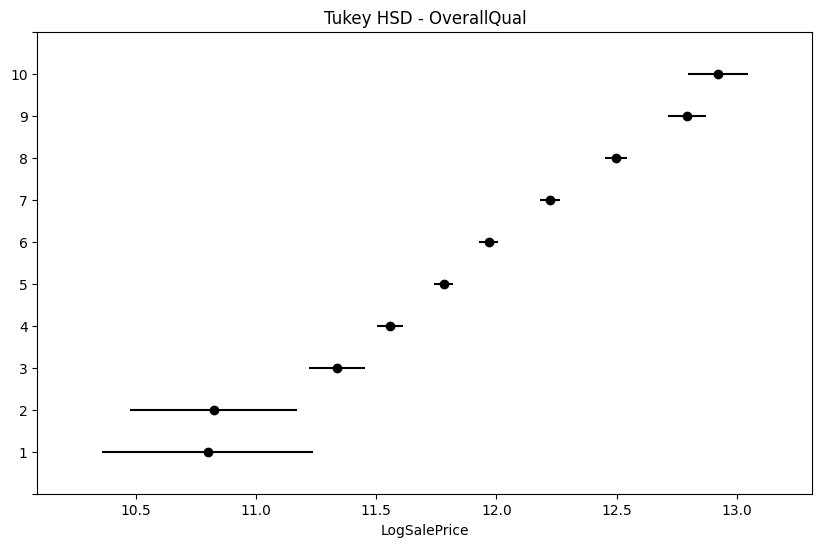


--- Tukey HSD for ExterQual ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
    Ex     Fa  -1.4595   0.0 -1.6868 -1.2322   True
    Ex     Gd  -0.4528   0.0 -0.5629 -0.3426   True
    Ex     TA  -0.9261   0.0 -1.0337 -0.8184   True
    Fa     Gd   1.0067   0.0  0.8021  1.2114   True
    Fa     TA   0.5334   0.0  0.3301  0.7368   True
    Gd     TA  -0.4733   0.0 -0.5157 -0.4309   True
---------------------------------------------------


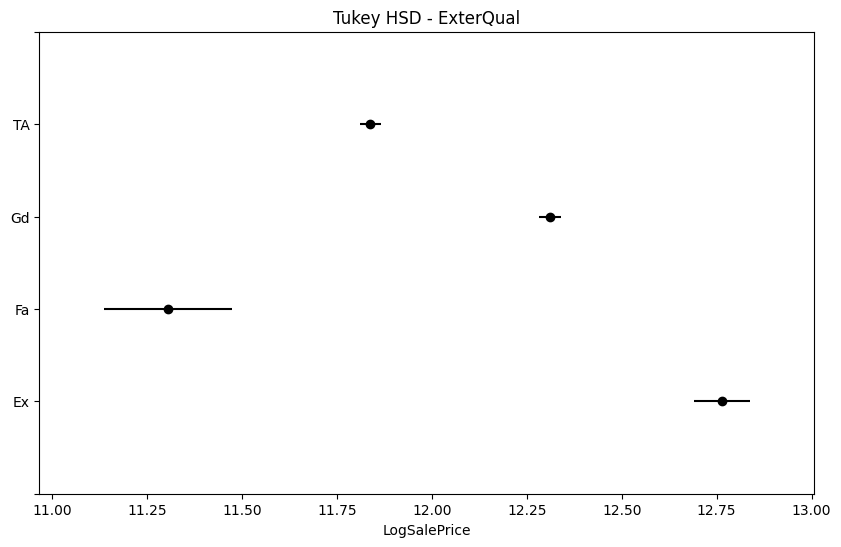


--- Tukey HSD for BsmtQual ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    Ex     Fa  -1.0228    0.0  -1.178 -0.8676   True
    Ex     Gd  -0.4605    0.0 -0.5409 -0.3801   True
    Ex   None  -1.1107    0.0 -1.2626 -0.9588   True
    Ex     TA  -0.8295    0.0 -0.9096 -0.7495   True
    Fa     Gd   0.5623    0.0  0.4218  0.7028   True
    Fa   None  -0.0879 0.7161 -0.2786  0.1027  False
    Fa     TA   0.1933 0.0016   0.053  0.3336   True
    Gd   None  -0.6502    0.0  -0.787 -0.5134   True
    Gd     TA   -0.369    0.0 -0.4145 -0.3236   True
  None     TA   0.2812    0.0  0.1445  0.4178   True
----------------------------------------------------


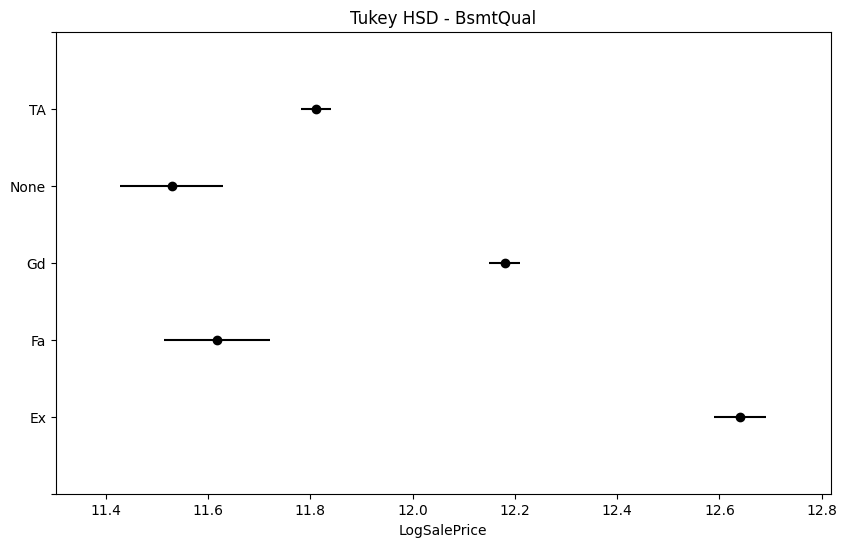


--- Tukey HSD for KitchenQual ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
    Ex     Fa   -1.129   0.0 -1.2733 -0.9847   True
    Ex     Gd  -0.4113   0.0  -0.494 -0.3286   True
    Ex     TA   -0.823   0.0 -0.9045 -0.7416   True
    Fa     Gd   0.7178   0.0  0.5914  0.8442   True
    Fa     TA    0.306   0.0  0.1804  0.4316   True
    Gd     TA  -0.4117   0.0 -0.4541 -0.3694   True
---------------------------------------------------


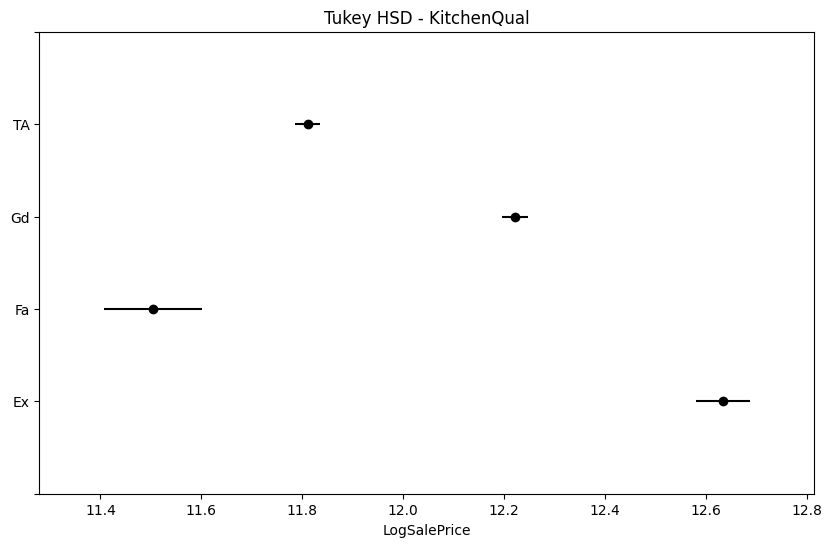


--- Tukey HSD for FireplaceQu ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    Ex     Fa  -0.6615    0.0 -0.9158 -0.4072   True
    Ex     Gd  -0.4135    0.0  -0.613  -0.214   True
    Ex   None  -0.8611    0.0 -1.0579 -0.6643   True
    Ex     Po  -0.9312    0.0 -1.2182 -0.6442   True
    Ex     TA  -0.4836    0.0 -0.6844 -0.2828   True
    Fa     Gd    0.248 0.0006   0.076    0.42   True
    Fa   None  -0.1996 0.0099 -0.3685 -0.0307   True
    Fa     Po  -0.2697 0.0484 -0.5383 -0.0011   True
    Fa     TA   0.1779 0.0406  0.0044  0.3514   True
    Gd   None  -0.4476    0.0 -0.5082 -0.3871   True
    Gd     Po  -0.5177    0.0 -0.7352 -0.3003   True
    Gd     TA  -0.0701 0.0637 -0.1425  0.0022  False
  None     Po  -0.0701 0.9387 -0.2851  0.1449  False
  None     TA   0.3775    0.0  0.3129  0.4421   True
    Po     TA   0.4476    0.0   0.229  0.6662   True
-----------

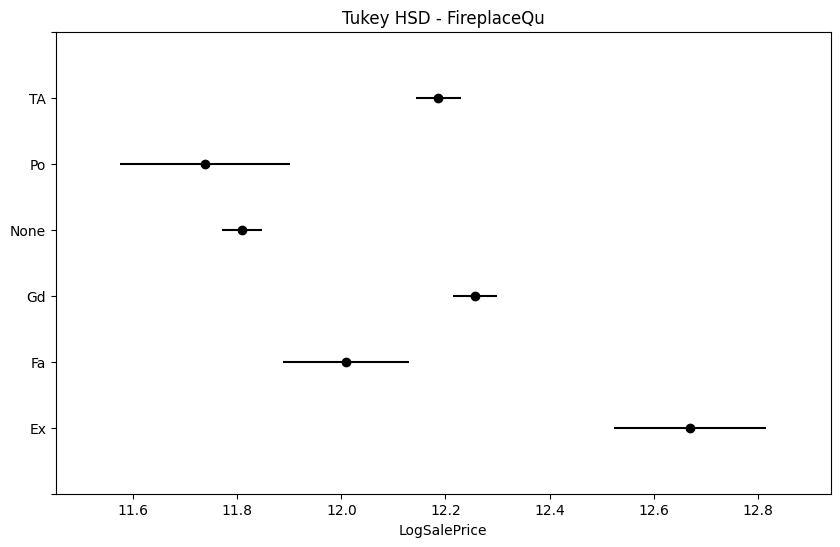


--- Tukey HSD for CentralAir ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper  reject
-------------------------------------------------
     N      Y   0.5692   0.0 0.4914 0.6471   True
-------------------------------------------------


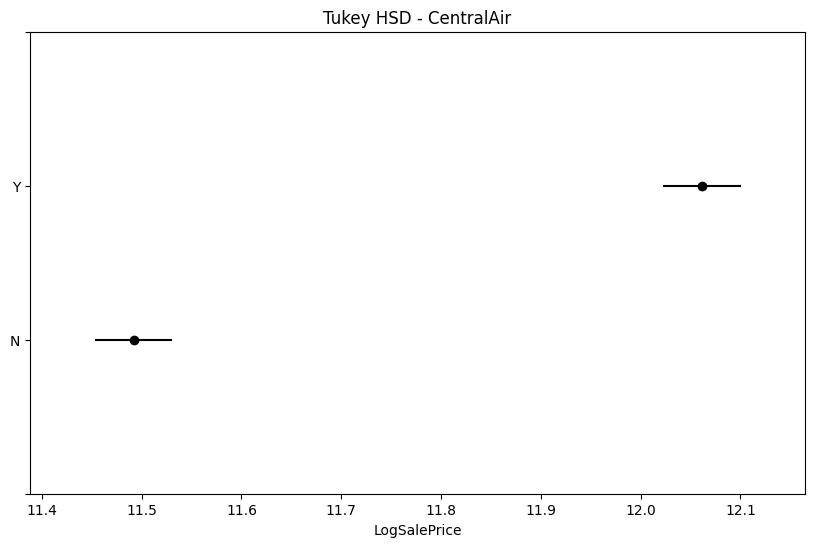


--- Tukey HSD for LotShape ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   IR1    IR2    0.155 0.0611 -0.0048  0.3148  False
   IR1    IR3   0.0419  0.986 -0.2719  0.3558  False
   IR1    Reg  -0.2274    0.0 -0.2825 -0.1723   True
   IR2    IR3   -0.113 0.8357 -0.4595  0.2334  False
   IR2    Reg  -0.3824    0.0 -0.5391 -0.2256   True
   IR3    Reg  -0.2693 0.1188 -0.5816   0.043  False
----------------------------------------------------


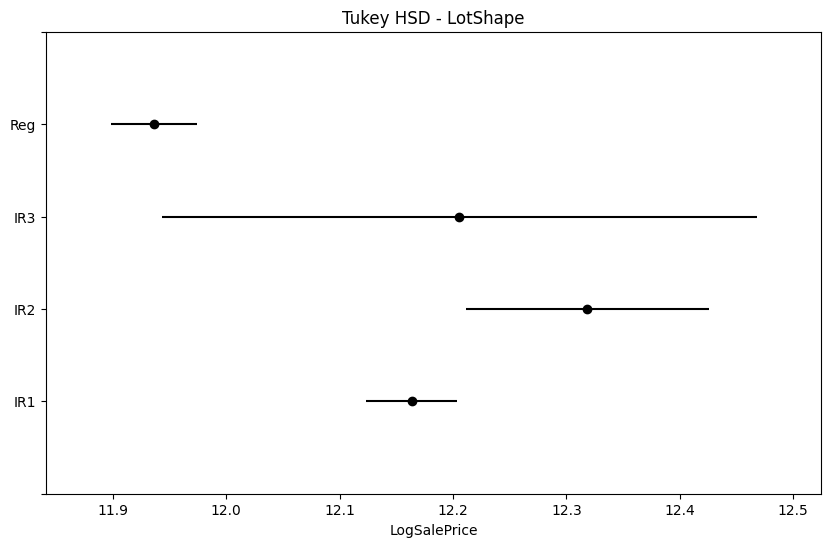


--- Tukey HSD for LandSlope ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
   Gtl    Mod   0.0563 0.5077 -0.0626 0.1752  False
   Gtl    Sev     0.11 0.5844 -0.1511 0.3711  False
   Mod    Sev   0.0537 0.8977  -0.231 0.3384  False
---------------------------------------------------


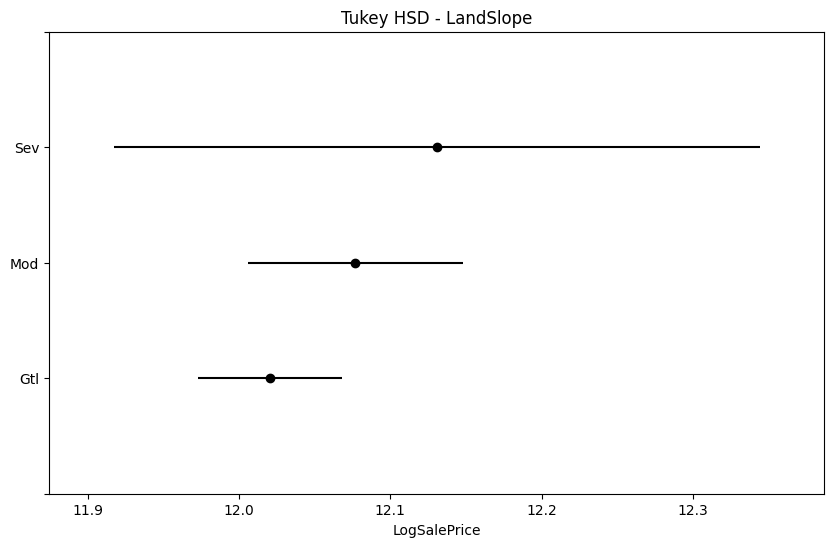


--- Tukey HSD for MoSold ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     1      2   0.0838 0.9948  -0.166 0.3335  False
     1      3   0.0668 0.9972 -0.1467 0.2804  False
     1      4   0.0088    1.0 -0.1952 0.2127  False
     1      5   0.0215    1.0  -0.173 0.2161  False
     1      6   0.0566 0.9982 -0.1337  0.247  False
     1      7   0.0795 0.9712 -0.1123 0.2713  False
     1      8   0.0858 0.9728 -0.1228 0.2943  False
     1      9   0.1353 0.7834 -0.1027 0.3732  False
     1     10   0.0568 0.9995 -0.1638 0.2775  False
     1     11   0.1115 0.9038 -0.1146 0.3376  False
     1     12    0.099 0.9738 -0.1428 0.3407  False
     2      3  -0.0169    1.0 -0.2383 0.2045  False
     2      4   -0.075 0.9919 -0.2871 0.1372  False
     2      5  -0.0622 0.9977 -0.2653 0.1409  False
     2      6  -0.0271    1.0 -0.2262  0.172  False
     2      7  -0.0043    1.0 -0.2

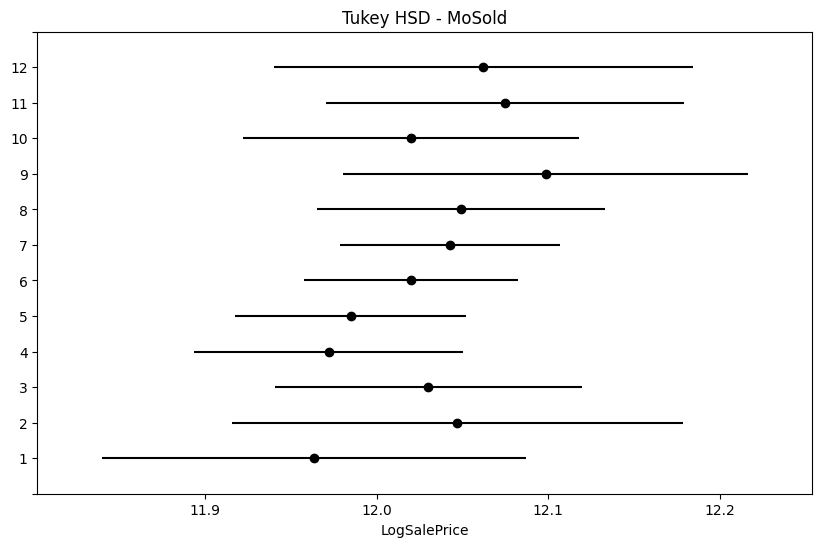


--- Tukey HSD for YrSold ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  2006   2007   0.0157 0.9876 -0.0704 0.1018  False
  2006   2008  -0.0208 0.9673 -0.1086  0.067  False
  2006   2009  -0.0262 0.9187 -0.1118 0.0593  False
  2006   2010  -0.0339 0.8971 -0.1369  0.069  False
  2007   2008  -0.0365 0.7814 -0.1233 0.0504  False
  2007   2009  -0.0419 0.6567 -0.1265 0.0426  False
  2007   2010  -0.0496 0.6747 -0.1517 0.0525  False
  2008   2009  -0.0055 0.9998 -0.0917 0.0808  False
  2008   2010  -0.0131 0.9969 -0.1167 0.0904  False
  2009   2010  -0.0077 0.9996 -0.1093  0.094  False
---------------------------------------------------


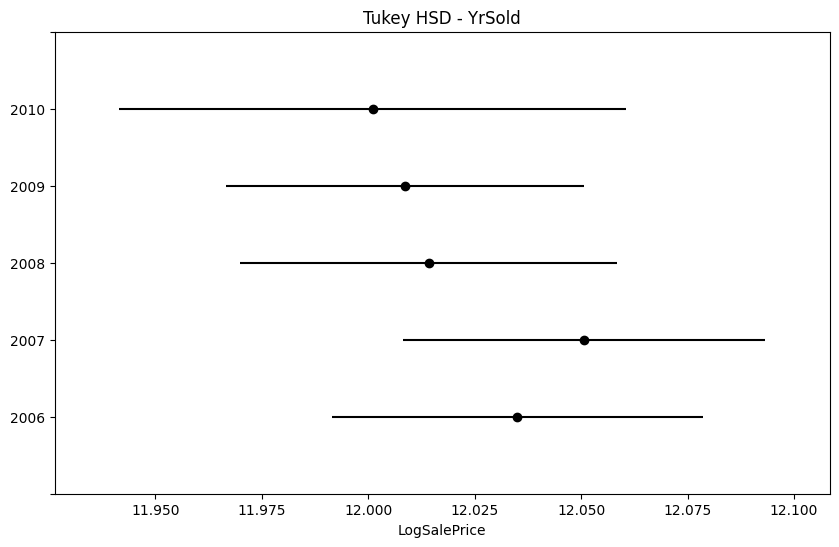

In [42]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
for col in features:
    tukey = pairwise_tukeyhsd(endog=train_anova['LogSalePrice'], groups=train_anova[col], alpha=0.05)
    print(f"\n--- Tukey HSD for {col} ---")
    print(tukey.summary())
    tukey.plot_simultaneous()
    plt.title(f'Tukey HSD - {col}')
    plt.xlabel('LogSalePrice')
    plt.show()

---
## Part 3: 2^k Factorial Design

Pick k binary (or binarized) factors from the significant features found in Part 2 and apply a factorial design analysis. For example you could binarize ordinal features into High/Low groups and study their joint effects.

**Tasks:**
- Select k factors (e.g. k=2 or k=3) and define High/Low levels
- Compute group means for all 2^k combinations
- Analyze main effects and interaction effects
- Visualize with interaction plots

In [ ]:
# Factors:
# A: OverallQual -> High (≥7) = +1, Low (<7) = -1
# B: KitchenQual -> High (Ex/Gd) = +1, Low (TA/Fa/Po) = -1
# C: CentralAir  -> Yes = +1, No = -1

# Number of factors
k = 3 

df_factorial = train[['LogSalePrice']].copy()
df_factorial['A'] = np.where(train['OverallQual'] >= 7, 1, -1)
df_factorial['B'] = np.where(train['KitchenQual'].isin(['Ex', 'Gd']), 1, -1)
df_factorial['C'] = np.where(train['CentralAir'] == 'Y', 1, -1)

# Number of total observations
N = len(df_factorial)
print(f"N = {N}")

N = 1460


In [53]:
# Group Means
def group_mean(a, b, c):
    mask = (df_factorial['A'] == a) & (df_factorial['B'] == b) & (df_factorial['C'] == c)
    return df_factorial.loc[mask, 'LogSalePrice'].mean()

treatment_comb_1 = group_mean(-1, -1, -1)
a_val = group_mean(-1, -1, -1)
b_val = group_mean(-1, 1, -1)
ab_val = group_mean(1, 1, -1)
c_val = group_mean(-1, -1, 1)
ac_val = group_mean(1, -1, 1)
bc_val = group_mean(-1, 1, 1)
abc_val = group_mean(1, 1, 1)

means_table = pd.DataFrame({
    'A': [-1, 1, -1, 1, -1, 1, -1, 1],
    'B': [-1, -1, 1, 1, -1, -1, 1, 1],
    'C': [-1, -1, -1, -1, 1, 1, 1, 1],
    'Mean LogSalePrice': [treatment_comb_1, a_val, b_val, ab_val, c_val, ac_val, bc_val, abc_val]
})

print("Group means for all 2^3 combinations:")
print(means_table)

Group means for all 2^3 combinations:
   A  B  C  Mean LogSalePrice
0 -1 -1 -1          11.442358
1  1 -1 -1          11.442358
2 -1  1 -1          11.835974
3  1  1 -1          12.250226
4 -1 -1  1          11.807476
5  1 -1  1          12.133962
6 -1  1  1          11.988174
7  1  1  1          12.412245


In [63]:
# Factor Effects
q_A = (1 / (2**k)) * (a_val +  ab_val + ac_val + abc_val - treatment_comb_1 - b_val - c_val - bc_val)
q_B = (1 / (2**k)) * (b_val + ab_val + bc_val + abc_val - treatment_comb_1 - a_val - c_val - ac_val)
q_C = (1 / (2**k)) * (c_val + ac_val + bc_val + abc_val - treatment_comb_1 - a_val - b_val - ab_val)
q_AB = (1 / (2**k)) * (ab_val + abc_val + treatment_comb_1 - a_val - b_val + c_val - ac_val - bc_val)
q_AC = (1 / (2**k)) * (treatment_comb_1 - a_val + b_val - ab_val + abc_val  - c_val + ac_val - bc_val)
q_BC = (1 / (2**k)) * (treatment_comb_1 + a_val - b_val - ab_val - c_val - ac_val + bc_val + abc_val)
q_ABC = (1 / (2**k)) * (abc_val - bc_val - ac_val + c_val - ab_val + b_val + a_val  - treatment_comb_1)

print("Factor Effects:")
print(f"q_A (OverallQual):                  {q_A:.4f}")
print(f"q_B (KitchenQual):                  {q_B:.4f}")
print(f"q_C (CentralAir):                   {q_C:.4f}")
print(f"q_AB (OverallQual and KitchenQual): {q_AB:.4f}")
print(f"q_AC (OverallQual and CentralAir):  {q_AC:.4f}")
print(f"q_BC (KitchenQual and CentralAir):  {q_BC:.4f}")
print(f"q_ABC (three factors):              {q_ABC:.4f}")


Factor Effects:
q_A (OverallQual):                  0.1456
q_B (KitchenQual):                  0.2076
q_C (CentralAir):                   0.1714
q_AB (OverallQual and KitchenQual): 0.0640
q_AC (OverallQual and CentralAir):  0.0420
q_BC (KitchenQual and CentralAir):  -0.0928
q_ABC (three factors):              -0.0396


In [ ]:
df_factorial.groupby(['A','B','C']).size()

A   B   C 
-1  -1  -1     86
         1    618
     1  -1      3
         1    205
 1  -1  -1      3
         1     67
     1  -1      3
         1    475
dtype: int64

We can see that in each of the 8 groups we have a different number of houses, it's very unbalanced ranging from 3 to 618 houses per group. So we'll use an approximation, we'll take the average group size for our replicate.

In [64]:
r_avg = N / (2**k)
r_avg

182.5

In [76]:
# Sum of Squares
SS_A = (2**k) * r_avg * q_A ** 2
SS_B = (2**k) * r_avg * q_B ** 2
SS_C = (2**k) * r_avg * q_C ** 2
SS_AB = (2**k) * r_avg * q_AB ** 2
SS_AC = (2**k) * r_avg * q_AC ** 2
SS_BC = (2**k) * r_avg * q_BC ** 2
SS_ABC = (2**k) * r_avg * q_ABC ** 2

SS_M = SS_A + SS_B + SS_C + SS_AB + SS_AC + SS_BC + SS_ABC

# overall mean and total sum of squares (SST)
q_0 = df_factorial["LogSalePrice"].mean()
SST = ((df_factorial["LogSalePrice"] - q_0)**2).sum()
SSE = SST - SS_M

print("Sum of Squares:")
for name, value in [('A', SS_A), ('B', SS_B), ('C', SS_C), ('AB', SS_AB), 
                    ('AC', SS_AC), ('BC', SS_BC), ('ABC', SS_ABC)]:
    print(f"SS_{name} = {value:.4f}")

print(f"\nModel Sum of Squares (SS_M) = {SS_M:.4f}")
print(f"Total Sum of Squares (SST)  = {SST:.4f}")
print(f"Sum of Squared Errors (SSE) = {SSE:.4f}")

Sum of Squares:
SS_A = 30.9515
SS_B = 62.8972
SS_C = 42.8756
SS_AB = 5.9763
SS_AC = 2.5801
SS_BC = 12.5767
SS_ABC = 2.2876

Model Sum of Squares (SS_M) = 160.1452
Total Sum of Squares (SST)  = 232.8007
Sum of Squared Errors (SSE) = 72.6555


In [84]:
# Degrees of freedom and Mean Squareds
df_A = df_B = df_C = df_AB = df_AC = df_BC = df_ABC = 1
df_M = 7
df_T = N - 1
df_E = df_T - df_M

MS_A = SS_A / df_A
MS_B = SS_B / df_B
MS_C = SS_C / df_C
MS_AB = SS_AB / df_AB
MS_AC = SS_AC / df_AC
MS_BC = SS_BC / df_BC
MS_ABC = SS_ABC / df_ABC
MSE = SSE / df_E

print("Mean Squares:")
for name, value in [('A', MS_A), ('B', MS_B), ('C', MS_C), ('AB', MS_AB), 
                    ('AC', MS_AC), ('BC', MS_BC), ('ABC', MS_ABC), ('E', MSE)]:
    print(f"MS_{name} = {value:.4f}")

Mean Squares:
MS_A = 30.9515
MS_B = 62.8972
MS_C = 42.8756
MS_AB = 5.9763
MS_AC = 2.5801
MS_BC = 12.5767
MS_ABC = 2.2876
MS_E = 0.0500


In [160]:
# F-statistics and p-value
F_A = MS_A / MSE
F_B = MS_B / MSE
F_C = MS_C / MSE
F_AB = MS_AB / MSE
F_AC = MS_AC / MSE
F_BC = MS_BC / MSE
F_ABC = MS_ABC / MSE



p_A = 1 - stats.f.cdf(F_A, df_A, df_E)
p_B = 1 - stats.f.cdf(F_B, df_B, df_E)
p_C = 1 - stats.f.cdf(F_C, df_C, df_E)
p_AB = 1 - stats.f.cdf(F_AB, df_AB, df_E)
p_AC = 1 - stats.f.cdf(F_AC, df_AC, df_E)
p_BC = 1 - stats.f.cdf(F_BC, df_BC, df_E)
p_ABC = 1 - stats.f.cdf(F_ABC, df_ABC, df_E)

print(f"{'Effect':<8} {'F-stat':>10} {'p-value':>12} {'Significant':>12}")
for name, F, p in [('A', F_A, p_A), ('B', F_B, p_B), ('C', F_C, p_C), ('AB', F_AB, p_AB), 
                   ('AC', F_AC, p_AC), ('BC', F_BC, p_BC), ('ABC', F_ABC, p_ABC)]:
    print(f"{name:<8} {F:>10.2f} {p:>12.6f} {'True' if p < 0.05 else 'False':>12}")

Effect       F-stat      p-value  Significant
A            618.56     0.000000         True
B           1256.98     0.000000         True
C            856.86     0.000000         True
AB           119.44     0.000000         True
AC            51.56     0.000000         True
BC           251.34     0.000000         True
ABC           45.72     0.000000         True


### Balanced Dataset Constraint

The classical $2^k$ factorial designs have a strict requirement for a perfectly balanced dataset, meaning that there are an equal number of observations (replicates) for every unique combination of factor levels.

In our dataset however, group sizes range from 3 to 618 houses which is far from balanced. Using $\text{r\_avg} = N/2^k = 182.5$ as an approximation, it inflates all SS values, resulting in a very small MSE (0.05) and extremely large F-statistics (600-1200), making every effect appear significant.

To address this, we use OLS regression which correctly handles unbalanced groups.

## Analysis using OLS

In [161]:
df_factorial['AB'] = df_factorial['A'] * df_factorial['B']
df_factorial['AC'] = df_factorial['A'] * df_factorial['C']
df_factorial['BC'] = df_factorial['B'] * df_factorial['C']
df_factorial['ABC'] = df_factorial['A'] * df_factorial['B'] * df_factorial['C']

model = ols('LogSalePrice ~ A + B + C + AB + AC + BC + ABC', data=df_factorial).fit()

anova_table_2k = sm.stats.anova_lm(model, typ=2)
print(anova_table_2k)

              sum_sq      df          F        PR(>F)
A           2.263776     1.0  32.332748  1.568118e-08
B           1.618743     1.0  23.119958  1.680149e-06
C           0.975621     1.0  13.934461  1.966053e-04
AB          0.020548     1.0   0.293476  5.880847e-01
AC          0.000851     1.0   0.012161  9.122034e-01
BC          0.136944     1.0   1.955921  1.621637e-01
ABC         0.002351     1.0   0.033573  8.546445e-01
Residual  101.661713  1452.0        NaN           NaN


In [182]:
# Extract SS and MSE from OLS table
SS_A = anova_table_2k.loc['A', 'sum_sq']
SS_B = anova_table_2k.loc['B', 'sum_sq']
SS_C = anova_table_2k.loc['C', 'sum_sq']
SS_AB = anova_table_2k.loc['AB', 'sum_sq']
SS_AC = anova_table_2k.loc['AC', 'sum_sq']
SS_BC = anova_table_2k.loc['BC', 'sum_sq']
SS_ABC = anova_table_2k.loc['ABC', 'sum_sq']
SSE = anova_table_2k.loc['Residual', 'sum_sq']
df_E = anova_table_2k.loc['Residual', 'df']
MSE = SSE / df_E

SS_M_ols= SS_A + SS_B + SS_C + SS_AB + SS_AC + SS_BC + SS_ABC
SST_ols = SS_M_ols + SSE

In [183]:
# Main Effects
SS_Main_Effects = SS_A + SS_B + SS_C
df_Main_Effects = 3
MS_Main_Effects = SS_Main_Effects / df_Main_Effects
F_Main_Effects = MS_Main_Effects / MSE
p_Main_Effects = 1 - stats.f.cdf(F_Main_Effects, df_Main_Effects, df_E)

print("Main Effects:")
print(f"SS      : {SS_Main_Effects}")
print(f"MS      : {MS_Main_Effects}")
print(f"F       : {F_Main_Effects}")
print(f"p-value : {p_Main_Effects}")

Main Effects:
SS      : 4.858139349321053
MS      : 1.6193797831070178
F       : 23.12905584376701
p-value : 1.2656542480726785e-14


In [184]:
# Two-Way Interaction Effects 
SS_Two_Way = SS_AB + SS_AC + SS_BC
df_Two_Way = 3
MS_Two_Way = SS_Two_Way / df_Two_Way
F_Two_Way = MS_Two_Way / MSE
p_Two_Way = 1 - stats.f.cdf(F_Two_Way, df_Two_Way, df_E)

print("Two-Way Interactions Effects:")
print(f"SS      : {SS_Two_Way}")
print(f"MS      : {MS_Two_Way}")
print(f"F       : {F_Two_Way}")
print(f"p-value : {p_Two_Way}")

Two-Way Interactions Effects:
SS      : 0.15834294180596098
MS      : 0.05278098060198699
F       : 0.7538529630707788
p-value : 0.5201152861839822


In [185]:
# Three-Way Interaction Effects 
SS_Three_Way = SS_ABC
df_Three_Way = 1
MS_Three_Way = SS_Three_Way / df_Three_Way
F_Three_Way = MS_Three_Way / MSE
p_Three_Way = 1 - stats.f.cdf(F_Three_Way, df_Three_Way, df_E)

print(f"SS      : {SS_Three_Way}")
print(f"MS      : {MS_Three_Way}")
print(f"F       : {F_Three_Way}")
print(f"p-value : {p_Three_Way}")

SS      : 0.002350584552466191
MS      : 0.002350584552466191
F       : 0.03357260720840662
p-value : 0.8546444769126137


In [186]:
# Model F-statistics and R^2
df_model = 7
df_T_ols = int(df_E) + df_model

MS_M = SS_M_ols / df_model
F_M = MS_M / MSE

R_square = SS_M_ols / SST_ols
R_square_adj = 1 - ((SSE / df_E) / (SST_ols / df_T_ols))

print("Model Statistics:")
print(f"MS_M    = {MS_M}")
print(f"F_M     = {F_M}")
print(f"R^2     = {R_square}")
print(f"R^2_adj = {R_square_adj}")

Model Statistics:
MS_M    = 0.7169761250970687
F_M     = 10.240328432531681
R^2     = 0.047045436619866904
R^2_adj = 0.04245130304985234


In [ ]:
# TO DO: Visualisations

---
## Part 4: Parametric Regression

Build a regression model using only the **significant ordinal features** identified by ANOVA (Part 2) plus the **2 numerical features**: `GrLivArea` and `TotalBsmtSF`.

**Tasks:**
- Encode ordinal features numerically (map quality levels to integers)
- Fit a linear regression model (OLS)
- Analyze the model: R², coefficient significance, residual plots
- Optionally try regularized regression (Ridge, Lasso) and compare
- Apply ANOVA on the regression model to assess factor contributions

---
## Part 5: Non-Parametric Model (Neural Network)

Build a neural network regression model using **all** available features to predict SalePrice. This is also the model that produces your `submission.csv` for Kaggle scoring.

**Tasks:**
- Preprocess all features: handle missing values, encode categoricals, scale numerics
- Build and train a neural network (e.g. `sklearn.neural_network.MLPRegressor` or PyTorch)
- Evaluate on training data (RMSE, R²) and analyze residuals
- Generate predictions for the test set and save as `submission.csv`

**Important:** The Kaggle RMSE score is evaluated on the predictions from this model.